In [1]:
import pandas as pd

In [3]:
df = pd.read_csv(r"D:\customer-segmentation\data\raw\Mall_Customers.csv")

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [12]:
(df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]] <= 0).sum()

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
Q1 = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].quantile(0.25)
Q3 = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bounds:")
print(lower_bound)

print("\nUpper Bounds:")
print(upper_bound)

Lower Bounds:
Age                       -1.625
Annual Income (k$)       -13.250
Spending Score (1-100)   -22.625
dtype: float64

Upper Bounds:
Age                        79.375
Annual Income (k$)        132.750
Spending Score (1-100)    130.375
dtype: float64


In [14]:
outlier_counts = ((df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]] < lower_bound) |
                  (df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]] > upper_bound)).sum()

print(outlier_counts)

Age                       0
Annual Income (k$)        2
Spending Score (1-100)    0
dtype: int64


In [15]:
df[df["Annual Income (k$)"] > upper_bound["Annual Income (k$)"]]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
198,199,Male,32,137,18
199,200,Male,30,137,83


Outlier Treatment: IQR analysis identified two potential outliers in Annual Income. On inspection, the records contained valid age, income, and spending-score values with no evidence of data-entry errors. Therefore, the observations were retained to preserve legitimate customer behavior.

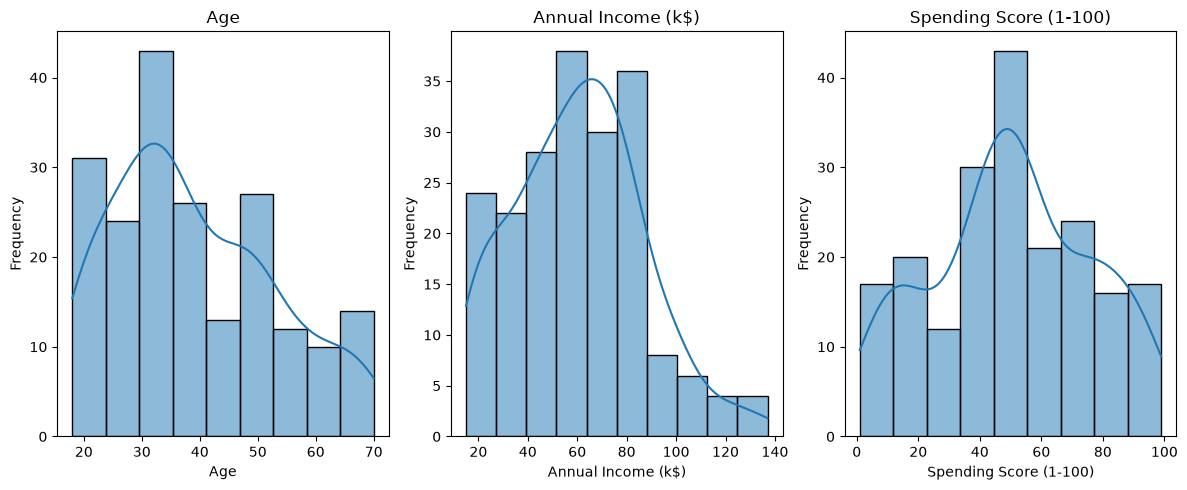

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

plt.figure(figsize=(12, 5))

for i, feature in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[feature], kde=True)
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

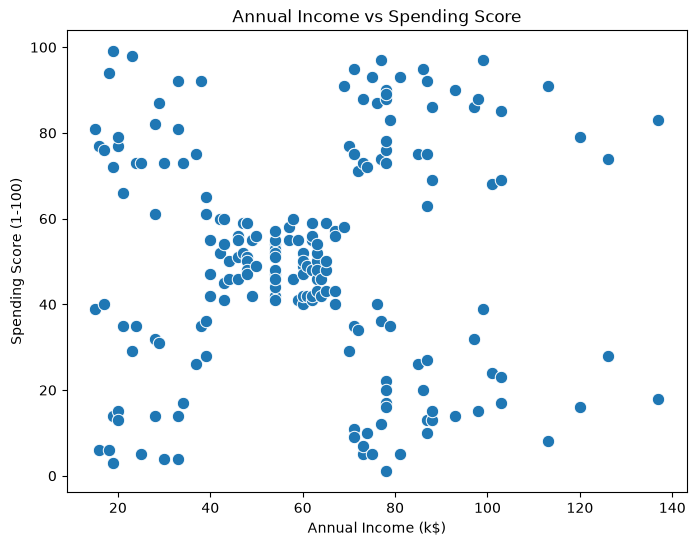

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [18]:
correlation = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()

print(correlation)

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


"Although Annual Income and Spending Score have almost zero linear correlation, the scatter plot reveals distinct patterns in the customer distribution. Therefore, correlation alone cannot determine cluster structure."

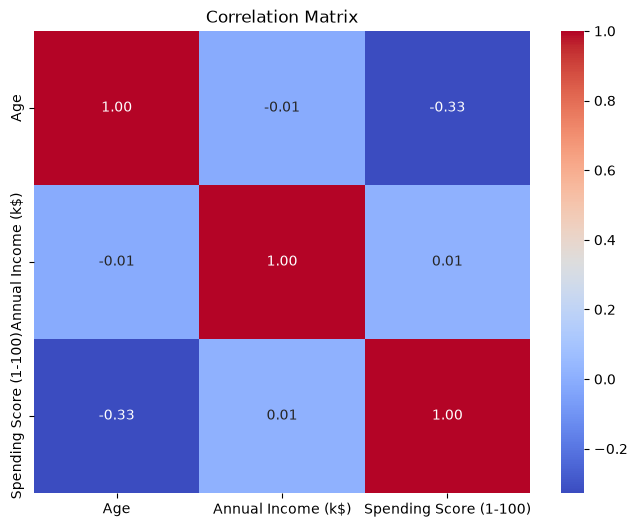

In [19]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()